In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim=256, scale=30.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
    
    def forward(self, x):
        # x: (B,) -> Noise levels
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class Dense(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.dense(x)[..., None, None]


class AdaptiveResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, embed_dim=256):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        
        self.norm1 = nn.GroupNorm(num_groups=32, num_channels=in_channels)
        self.norm2 = nn.GroupNorm(num_groups=32, num_channels=out_channels)
        
        self.embed_layers = nn.ModuleList([
            nn.Linear(embed_dim, out_channels * 2), 
        ])
        
        self.act = nn.SiLU() 

    def forward(self, x, embed):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        
        h = self.norm2(h)
        style = self.embed_layers[0](embed)
        style = style.view(style.shape[0], 2, -1, 1, 1)
        scale, shift = style[:, 0], style[:, 1]
        
        h = h * (1 + scale) + shift
        h = self.act(h)
        h = self.conv2(h)
        
        return h + self.shortcut(x)

class ScoreNet(nn.Module):
    def __init__(self, num_classes=None):
        super().__init__()
        
        # Embedding Layer
        self.embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=256),
            nn.Linear(256, 256),
            nn.SiLU()
        )
        
        # Input
        self.input_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        
        # Encoder 1
        self.enc1 = AdaptiveResBlock(64, 64)
        self.down1 = nn.AvgPool2d(2) # Down 1
        
        # Encoder 2
        self.enc2 = AdaptiveResBlock(64, 128)
        self.down2 = nn.AvgPool2d(2) # Down 2
        
        # Encoder 3
        self.enc3 = AdaptiveResBlock(128, 256)


        self.dec1 = AdaptiveResBlock(256 + 128, 128) 
        

        self.dec2 = AdaptiveResBlock(128 + 64, 64)
        
        # Output
        self.output_conv = nn.Conv2d(64, 1, kernel_size=3, padding=1)
        
    def forward(self, x, sigma):


        embed = self.embed(sigma)
        

        h = self.input_conv(x)          # (B, 64, 28, 28)
        
        h1 = self.enc1(h, embed)
        h = self.down1(h1)              # (B, 64, 14, 14)
        
        h2 = self.enc2(h, embed)
        h = self.down2(h2)              # (B, 128, 7, 7)
        
        h3 = self.enc3(h, embed)        # (B, 256, 7, 7)
 
        h_up1 = F.interpolate(h3, scale_factor=2, mode='nearest') # (B, 256, 14, 14)

        h = torch.cat([h_up1, h2], dim=1) 
        h = self.dec1(h, embed)         # (B, 128, 14, 14)
        
        # Up 2
        h_up2 = F.interpolate(h, scale_factor=2, mode='nearest') # (B, 128, 28, 28)

        h = torch.cat([h_up2, h1], dim=1)
        h = self.dec2(h, embed)         # (B, 64, 28, 28)
        
        # Output
        out = self.output_conv(h)
        
        out = out / sigma[:, None, None, None]
        
        return out

In [6]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(), 
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

train_loader_score = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)


In [7]:
def show_images(images, title="Images"):
    grid_img = images.detach().cpu().numpy()
    grid_img = grid_img.transpose(0, 2, 3, 1)
    
    plt.figure(figsize=(10, 2))
    for i in range(min(10, len(images))):
        plt.subplot(1, 10, i + 1)
        plt.imshow(grid_img[i].squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

In [8]:
sigma_begin = 30.0
sigma_end = 0.01
num_levels = 10
batch_size = 64
lr = 2e-4
epochs = 30
T_steps = 150 # Langevin Steps per level
step_lr = 2e-5 # epsilon

# The exponential series of noises.
sigmas = torch.exp(torch.linspace(np.log(sigma_begin), np.log(sigma_end), num_levels)).to(device)

train_loader_score = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

In [9]:
score_model = ScoreNet().to(device)
optimizer = optim.Adam(score_model.parameters(), lr=lr)

print("Starting ScoreNet Training...")
losses = []

for epoch in range(epochs):
    avg_loss = 0
    for x, _ in train_loader_score:
        x = x.to(device)
        rand_indices = torch.randint(0, num_levels, (x.size(0),), device=device)
        used_sigmas = sigmas[rand_indices].view(-1, 1, 1, 1) # (B, 1, 1, 1)
        

        z = torch.randn_like(x)
        x_noisy = x + used_sigmas * z

        score_pred = score_model(x_noisy, sigmas[rand_indices])
        
        target = -z / used_sigmas
        
        # Weighted MSE: weight * ||pred - target||^2
        # Weight = sigma^2
        loss = 0.5 * ((score_pred - target) ** 2).sum(dim=(1, 2, 3)) * (used_sigmas.view(-1) ** 2)
        loss = loss.mean()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        avg_loss += loss.item()
        
    avg_loss /= len(train_loader_score)
    losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

save_path = "scorenet_final.pth"

torch.save(score_model.state_dict(), save_path)
print(f"Model weights saved to {save_path}")
print("Training Finished.")

Starting ScoreNet Training...
Epoch [1/30], Loss: 43.1648
Epoch [2/30], Loss: 24.3382
Epoch [3/30], Loss: 22.6606
Epoch [4/30], Loss: 21.9010
Epoch [5/30], Loss: 21.3774
Epoch [6/30], Loss: 21.1658
Epoch [7/30], Loss: 20.5990
Epoch [8/30], Loss: 20.6401
Epoch [9/30], Loss: 20.2738
Epoch [10/30], Loss: 20.0358
Epoch [11/30], Loss: 20.1562
Epoch [12/30], Loss: 19.9202
Epoch [13/30], Loss: 19.8656
Epoch [14/30], Loss: 19.7173
Epoch [15/30], Loss: 19.9141
Epoch [16/30], Loss: 19.6528
Epoch [17/30], Loss: 19.4477
Epoch [18/30], Loss: 19.6146
Epoch [19/30], Loss: 19.4721
Epoch [20/30], Loss: 19.3426
Epoch [21/30], Loss: 19.2935
Epoch [22/30], Loss: 19.2221
Epoch [23/30], Loss: 19.1316
Epoch [24/30], Loss: 19.0935
Epoch [25/30], Loss: 19.1722
Epoch [26/30], Loss: 18.9785
Epoch [27/30], Loss: 18.9624
Epoch [28/30], Loss: 18.9678
Epoch [29/30], Loss: 18.9472
Epoch [30/30], Loss: 18.7756
Model weights saved to scorenet_final.pth
Training Finished.


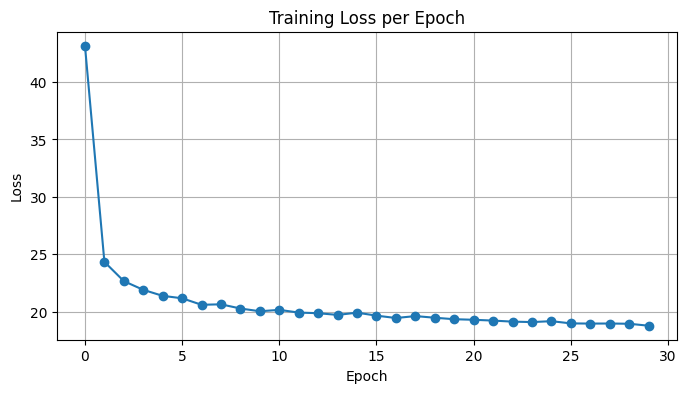

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(losses, marker='o')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("loss_plot.png")
plt.show()

Generating samples with NCSN...
Finished noise level 2/10 (sigma=12.3246)
Finished noise level 4/10 (sigma=2.0801)
Finished noise level 6/10 (sigma=0.3511)
Finished noise level 8/10 (sigma=0.0593)
Finished noise level 10/10 (sigma=0.0100)


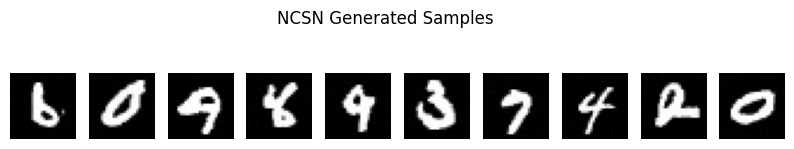

In [11]:
def annealed_langevin_dynamics(model, sigmas, n_samples=16, steps_per_level=150, step_lr=2e-5):
    x = torch.rand(n_samples, 1, 28, 28).to(device) 
    
    model.eval()
    trajectories = []
    
    with torch.no_grad():
        for i, sigma in enumerate(sigmas):
            alpha = step_lr * (sigma / sigmas[-1]) ** 2
            
            for t in range(steps_per_level):

                sigma_input = torch.ones(n_samples, device=device) * sigma
                score = model(x, sigma_input)
                
                z = torch.randn_like(x)
                if i == len(sigmas) - 1 and t == steps_per_level - 1:
                    z = 0
                    
                x = x + alpha / 2 * score + torch.sqrt(alpha) * z
            
            trajectories.append(x.clone())
            
            if (i+1) % 2 == 0:
                print(f"Finished noise level {i+1}/{len(sigmas)} (sigma={sigma:.4f})")
                
    return x.clamp(0, 1), trajectories

print("Generating samples with NCSN...")
final_samples, _ = annealed_langevin_dynamics(score_model, sigmas, steps_per_level=T_steps, step_lr=step_lr)
show_images(final_samples.cpu(), title="NCSN Generated Samples")

Generating samples...


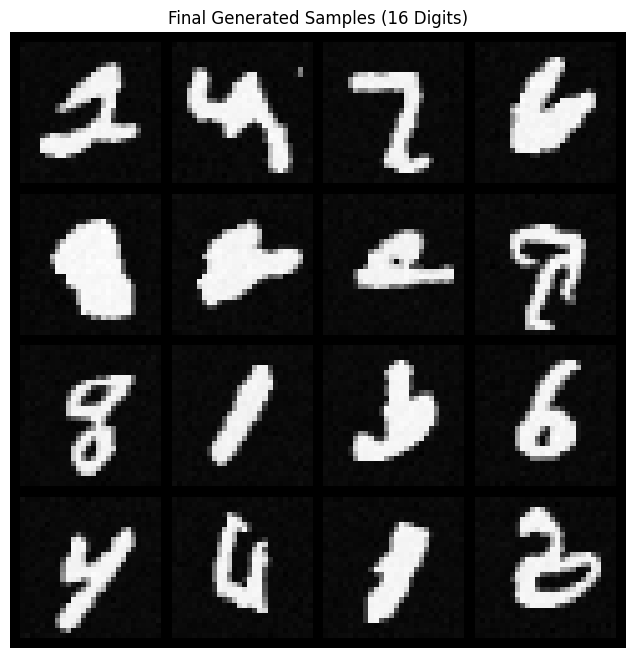

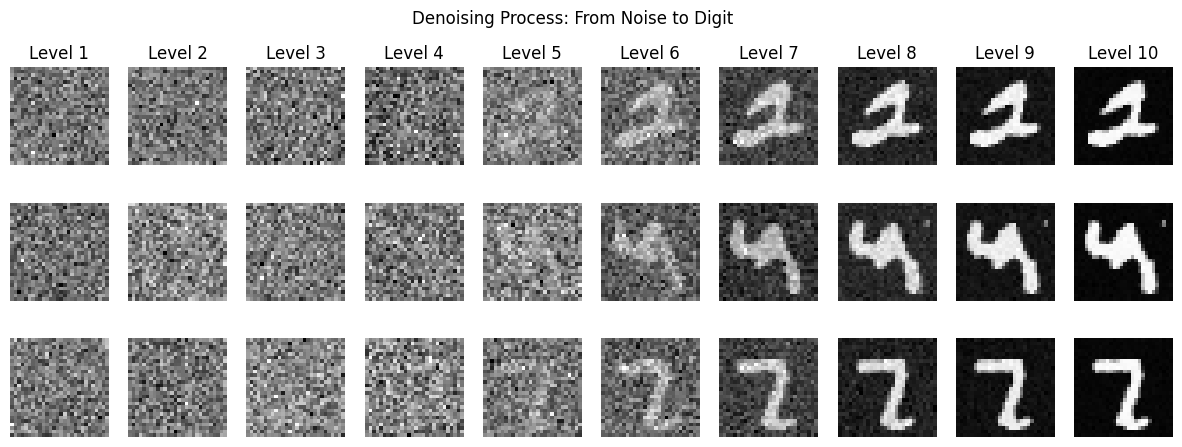

In [15]:
from torchvision.utils import make_grid
def annealed_langevin_dynamics(model, sigmas, n_samples=16, steps_per_level=100, step_lr=2e-5):
    x = torch.rand(n_samples, 1, 28, 28).to(device)

    trajectories = [] 
    
    with torch.no_grad():
        for i, sigma in enumerate(sigmas):
            alpha = step_lr * (sigma / sigmas[-1]) ** 2
            for t in range(steps_per_level):
                sigma_input = torch.ones(n_samples, device=device) * sigma
                score = score_model(x, sigma_input)
                
                z = torch.randn_like(x)
                if i == len(sigmas) - 1 and t == steps_per_level - 1:
                    z = 0
                
                x = x + alpha / 2 * score + torch.sqrt(alpha) * z
            
            trajectories.append(x[:3].clone().cpu())
            
    return x.cpu(), trajectories

print("Generating samples...")
final_samples, trajectories = annealed_langevin_dynamics(score_model, sigmas, n_samples=16, steps_per_level=100)

plt.figure(figsize=(8, 8))
grid_img = make_grid(final_samples, nrow=4, padding=2, normalize=True)
plt.imshow(grid_img.permute(1, 2, 0))
plt.title("Final Generated Samples (16 Digits)")
plt.axis('off')
plt.savefig("final_grid.png")
plt.show()

num_snapshots = len(trajectories)
plt.figure(figsize=(15, 5))

for i in range(3):
    for j in range(num_snapshots):
        plt.subplot(3, num_snapshots, i * num_snapshots + j + 1)
        plt.imshow(trajectories[j][i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title(f"Level {j+1}")

plt.suptitle("Denoising Process: From Noise to Digit")
plt.savefig("denoising_process.png")
plt.show()